# Overall Metrics — Boxplot per Model

Instead of collapsing all smells into a single bar per model, this notebook shows the **distribution of each metric across the 5 smells** for every model via boxplots with individual data points overlaid.

Each box summarises 5 observations (one per smell: Cyclic Dep., MS Greedy, Nano Service, No API GW, Shared DB).  
Individual points are jitter-plotted on top so no information is hidden.

**Scale (both ground truth and LLM confidence):** 1 = definitely absent · 2 = probably absent · 3 = probably present · 4 = definitely present  
**Binary threshold:** mean score ≥ 3 → **present** (positive)

In [1]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

RESULTS_DIR = Path('../results')
GT_CSV      = Path('../ground-truth/final-ground-truth.csv')
THRESHOLD   = 3

SMELLS = [
    'cyclic_dependency',
    'microservice_greedy',
    'nano_service',
    'no_api_gateway',
    'shared_database',
]
SMELL_LABELS = {
    'cyclic_dependency':   'Cyclic Dep.',
    'microservice_greedy': 'MS Greedy',
    'nano_service':        'Nano Service',
    'no_api_gateway':      'No API GW',
    'shared_database':     'Shared DB',
}

MODEL_DISPLAY_NAMES = {
    'Llama-4-Maverick-17B-128E-Instruct-FP8-e81efef6': 'llama-4-maverick',
}

# General Purpose: gpt, gemini, llama  |  Coding Specific: codex, claude, qwen
MODEL_ORDER = ['gpt-5.4', 'gemini-2.5-pro', 'llama-4-maverick',
               'gpt-5.3-codex', 'claude-sonnet-4-6', 'qwen-vl-max']

MODEL_CATEGORY = {
    'gpt-5.4':           'General Purpose',
    'gemini-2.5-pro':    'General Purpose',
    'llama-4-maverick':  'General Purpose',
    'gpt-5.3-codex':     'Coding Specific',
    'claude-sonnet-4-6': 'Coding Specific',
    'qwen-vl-max':       'Coding Specific',
}
CATEGORY_ORDER  = ['General Purpose', 'Coding Specific']
CATEGORY_COLORS = {'General Purpose': '#4C72B0', 'Coding Specific': '#C44E52'}

# Boxplot x-positions: GP = 1,2,3  |  CS = 4,5,6  →  boundary at 3.5
CATEGORY_BOUNDARIES = [3.5]
CAT_CENTERS         = [2.0, 5.0]

print('Setup done.')

Setup done.


In [2]:
# Ground Truth

GT_COL_MAP = {
    'CD':  'cyclic_dependency',
    'MG':  'microservice_greedy',
    'NS':  'nano_service',
    'NAG': 'no_api_gateway',
    'SD':  'shared_database',
}

gt_raw = pd.read_csv(GT_CSV)
gt_raw = gt_raw[pd.to_numeric(gt_raw['DIAGRAMS'], errors='coerce').notna()].copy()
gt_raw['sys_id'] = gt_raw['DIAGRAMS'].astype(int).astype(str)

gt_rows = []
for col, smell in GT_COL_MAP.items():
    sub = gt_raw[['sys_id', col]].copy()
    sub.columns = ['sys_id', 'score']
    sub['smell'] = smell
    gt_rows.append(sub)

gt_long = pd.concat(gt_rows, ignore_index=True)
gt_long['score'] = pd.to_numeric(gt_long['score'], errors='coerce')

gt_agg = (
    gt_long
    .groupby(['sys_id', 'smell'])['score']
    .mean()
    .reset_index()
    .rename(columns={'score': 'gt_mean'})
)
gt_agg['gt_label'] = (gt_agg['gt_mean'] >= THRESHOLD).astype(int)

print(f'Ground truth rows: {len(gt_agg)}')

Ground truth rows: 45


In [3]:
# LLM Predictions

pred_rows = []

for run_file in sorted(RESULTS_DIR.rglob('run_*.json')):
    smell_dir = run_file.parent
    if smell_dir.name not in SMELLS:
        continue
    sys_dir = smell_dir.parent
    m = re.match(r'^(\d+)', sys_dir.name)
    if not m:
        continue
    sys_id = m.group(1)
    raw_model = sys_dir.parent.name
    model_name = MODEL_DISPLAY_NAMES.get(raw_model, raw_model)

    with open(run_file) as f:
        data = json.load(f)
    confidence = data.get('confidence')
    if confidence is not None:
        pred_rows.append({
            'model':      model_name,
            'sys_id':     sys_id,
            'smell':      smell_dir.name,
            'confidence': float(confidence),
        })

pred_df = pd.DataFrame(pred_rows)

pred_agg = (
    pred_df
    .groupby(['model', 'sys_id', 'smell'])['confidence']
    .mean()
    .reset_index()
    .rename(columns={'confidence': 'pred_mean'})
)
pred_agg['pred_label'] = (pred_agg['pred_mean'] >= THRESHOLD).astype(int)

print(f'Total prediction rows: {len(pred_agg)}')

Total prediction rows: 270


In [4]:
# Merge and compute TP / FP / TN / FN

merged = pred_agg.merge(gt_agg[['sys_id', 'smell', 'gt_mean', 'gt_label']], on=['sys_id', 'smell'], how='inner')

merged['TP'] = ((merged['pred_label'] == 1) & (merged['gt_label'] == 1)).astype(int)
merged['FP'] = ((merged['pred_label'] == 1) & (merged['gt_label'] == 0)).astype(int)
merged['TN'] = ((merged['pred_label'] == 0) & (merged['gt_label'] == 0)).astype(int)
merged['FN'] = ((merged['pred_label'] == 0) & (merged['gt_label'] == 1)).astype(int)

print(f'Merged rows: {len(merged)}')

Merged rows: 270


In [5]:
# Metrics helper

def metrics_from(group):
    tp = group['TP'].sum()
    fp = group['FP'].sum()
    tn = group['TN'].sum()
    fn = group['FN'].sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0.0)
    mcc_denom = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = (tp * tn - fp * fn) / mcc_denom if mcc_denom > 0 else 0.0
    return pd.Series({
        'Precision': round(float(precision), 3),
        'Recall':    round(float(recall), 3),
        'F1':        round(float(f1), 3),
        'MCC':       round(float(mcc), 3),
    })

# Per-smell metrics for each model  →  the raw data behind each boxplot
per_smell = (
    merged
    .groupby(['model', 'smell'])
    .apply(metrics_from, include_groups=False)
    .reset_index()
)

print('Per-smell metrics shape:', per_smell.shape)
display(per_smell.head(10))

Per-smell metrics shape: (30, 6)


,model,smell,Precision,Recall,F1,MCC
0,claude-sonnet-4-6,cyclic_dependency,0.00,0.00,0.00,0.000
1,claude-sonnet-4-6,microservice_greedy,0.75,0.75,0.75,0.550
2,claude-sonnet-4-6,nano_service,1.00,0.25,0.40,0.395
3,claude-sonnet-4-6,no_api_gateway,1.00,1.00,1.00,1.000
4,claude-sonnet-4-6,shared_database,0.00,0.00,0.00,0.000
5,gemini-2.5-pro,cyclic_dependency,0.00,0.00,0.00,0.000
6,gemini-2.5-pro,microservice_greedy,0.75,0.75,0.75,0.550
7,gemini-2.5-pro,nano_service,0.75,0.75,0.75,0.550
8,gemini-2.5-pro,no_api_gateway,1.00,1.00,1.00,1.000
9,gemini-2.5-pro,shared_database,0.00,0.00,0.00,0.000


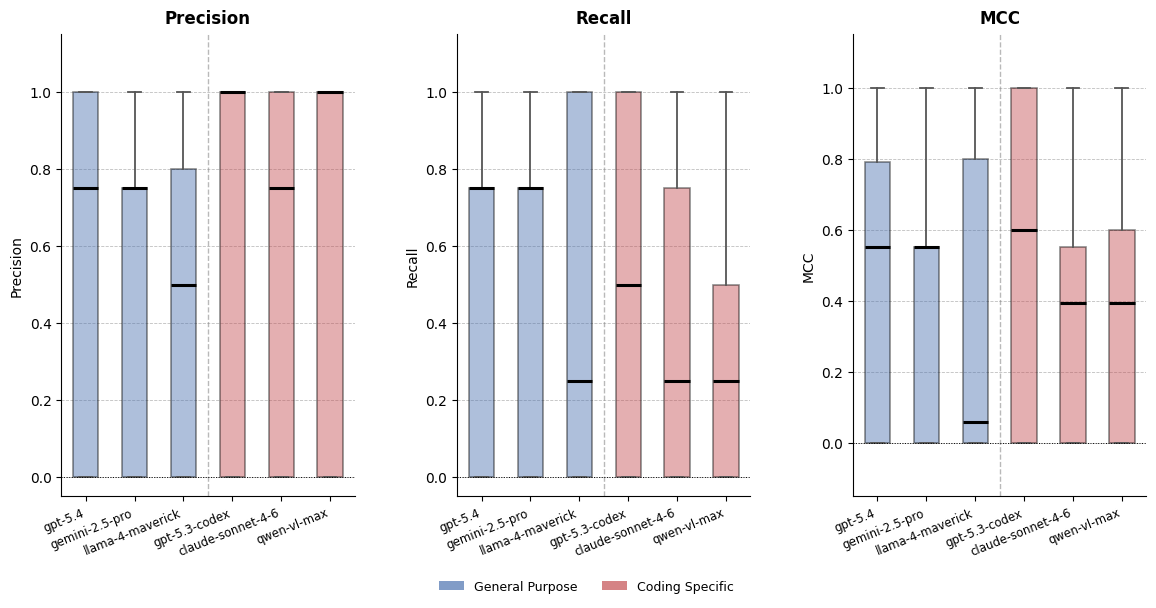

In [9]:
# ── Boxplot: distribuição de cada métrica por smell, um box por modelo ────────

METRICS     = ['Precision', 'Recall', 'MCC']
METRIC_YLIM = {'Precision': (-0.05, 1.15),
               'Recall':    (-0.05, 1.15),
               'MCC':       (-0.15, 1.15)}
METRIC_COLORS = {'Precision': '#000', 'Recall': '#000', 'MCC': '#000'}  # PuOr

CAT_CENTERS_BOX = [2.0, 5.0]

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=False)
fig.subplots_adjust(wspace=0.35)

for ax, metric in zip(axes, METRICS):
    data_per_model = [
        per_smell.loc[per_smell['model'] == m, metric].values
        for m in MODEL_ORDER
    ]
    cat_colors   = [CATEGORY_COLORS[MODEL_CATEGORY[m]] for m in MODEL_ORDER]
    metric_color = METRIC_COLORS[metric]

    bp = ax.boxplot(
        data_per_model,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2.2),
        whiskerprops=dict(linewidth=1.3, color='#555555'),
        capprops=dict(linewidth=1.3, color='#555555'),
        boxprops=dict(linewidth=1.2),
        flierprops=dict(marker='', linestyle='none'),
        widths=0.52,
    )

    for patch, cat_color in zip(bp['boxes'], cat_colors):
        patch.set_facecolor(cat_color)
        patch.set_alpha(0.45)

    ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5, color='gray')
    ax.set_axisbelow(True)

    for sep_x in CATEGORY_BOUNDARIES:
        ax.axvline(sep_x, color='gray', linewidth=1.0, linestyle='--', alpha=0.55)

    ax.set_xticks(range(1, len(MODEL_ORDER) + 1))
    ax.set_xticklabels(MODEL_ORDER, rotation=22, ha='right', fontsize=8.5)
    ax.set_ylim(*METRIC_YLIM[metric])
    ax.set_ylabel(metric, fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight='bold', color=metric_color, pad=8)
    ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_handles = [
    mpatches.Patch(facecolor=CATEGORY_COLORS[c], alpha=0.7, label=c)
    for c in CATEGORY_ORDER
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=2,
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(0.5, -0.07),
)

plt.savefig('metrics_overall_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

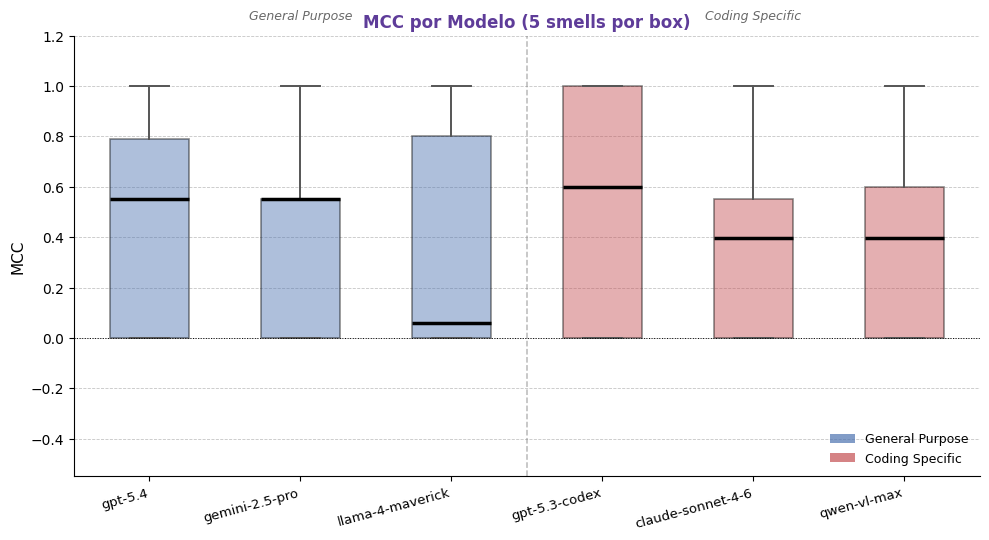

In [7]:
# ── Boxplot compacto: MCC por modelo ──────────────────────────────────────────

FOCUS_METRIC    = 'MCC'
CAT_CENTERS_BOX = [2.0, 5.0]

data_per_model = [
    per_smell.loc[per_smell['model'] == m, FOCUS_METRIC].values
    for m in MODEL_ORDER
]
cat_colors = [CATEGORY_COLORS[MODEL_CATEGORY[m]] for m in MODEL_ORDER]

fig, ax = plt.subplots(figsize=(10, 5.5))

bp = ax.boxplot(
    data_per_model,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(linewidth=1.4, color='#555555'),
    capprops=dict(linewidth=1.4, color='#555555'),
    boxprops=dict(linewidth=1.2),
    flierprops=dict(marker='', linestyle='none'),
    widths=0.52,
)

for patch, cat_color in zip(bp['boxes'], cat_colors):
    patch.set_facecolor(cat_color)
    patch.set_alpha(0.45)

ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.45, color='gray')
ax.set_axisbelow(True)

for sep_x in CATEGORY_BOUNDARIES:
    ax.axvline(sep_x, color='gray', linewidth=1.1, linestyle='--', alpha=0.55)

for label, center in zip(CATEGORY_ORDER, CAT_CENTERS_BOX):
    ax.text(center, 1.03, label, ha='center', va='bottom',
            fontsize=9, style='italic', color='dimgray',
            transform=ax.get_xaxis_transform())

ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
ax.set_xticks(range(1, len(MODEL_ORDER) + 1))
ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right', fontsize=9.5)
ax.set_ylim(-0.55, 1.2)
ax.set_ylabel('MCC', fontsize=11)
ax.set_title(
    'MCC por Modelo (5 smells por box)',
    fontsize=12, fontweight='bold', color='#5E3C99',
)

legend_handles = [
    mpatches.Patch(facecolor=CATEGORY_COLORS[c], alpha=0.7, label=c)
    for c in CATEGORY_ORDER
]
ax.legend(handles=legend_handles, fontsize=9, frameon=False, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('metrics_overall_boxplot_mcc.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Tabela de estatísticas resumidas ──────────────────────────────────────────

rows = []
for model in MODEL_ORDER:
    sub = per_smell[per_smell['model'] == model]
    for metric in METRICS:
        vals = sub[metric].values
        rows.append({
            'Model':  model,
            'Metric': metric,
            'Median': round(np.median(vals), 3),
            'IQR':    round(float(np.percentile(vals, 75) - np.percentile(vals, 25)), 3),
            'Min':    round(float(vals.min()), 3),
            'Max':    round(float(vals.max()), 3),
        })

summary = pd.DataFrame(rows)
display(
    summary.pivot_table(
        index='Model',
        columns='Metric',
        values=['Median', 'IQR'],
        aggfunc='first',
    ).reindex(MODEL_ORDER)
)

IQR                  Median                 
Metric               MCC Precision Recall    MCC Precision Recall
Model                                                            
gpt-5.4            0.791      1.00   0.75  0.550      0.75   0.75
gemini-2.5-pro     0.550      0.75   0.75  0.550      0.75   0.75
llama-4-maverick   0.800      0.80   1.00  0.060      0.50   0.25
gpt-5.3-codex      1.000      1.00   1.00  0.598      1.00   0.50
claude-sonnet-4-6  0.550      1.00   0.75  0.395      0.75   0.25
qwen-vl-max        0.598      1.00   0.50  0.395      1.00   0.25